# 03 · Choix du modèle

**Question : quel modèle retenir ?** On part du plus simple et on ne complexifie que si le gain est mesurable.

| Modèle | Rôle |
|---|---|
| Naïf 24 h (`lag_48`) | « demain = aujourd'hui » : le niveau minimum à battre |
| Naïf 7 jours (`lag_336`) | « demain = même jour la semaine dernière » |
| Régression linéaire | modèle simple et interprétable |
| LightGBM | gradient boosting, capture les interactions non linéaires |

Ce notebook reproduit la comparaison faite par `src/train.py` (qui l'enregistre dans MLflow).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True, "grid.alpha": 0.3})

from lightgbm import LGBMRegressor, early_stopping

from src.config import load_params
from src.data import load_dataset, temporal_split
from src.features import FEATURE_COLUMNS
from src.models import NAIVE_MODELS, lightgbm, linear_regression, score

params = load_params()
fit, validation, test = temporal_split(load_dataset(), params["split"])
sets = {"train": fit, "validation": validation, "test": test}
X, y = FEATURE_COLUMNS, "consommation_mw"


def evaluate(predict) -> dict:
    return {f"{name}_{metric}": value for name, frame in sets.items() for metric, value in score(frame[y], predict(frame)).items()}

In [2]:
results, models = {}, {}
for name, column in NAIVE_MODELS.items():
    results[name] = evaluate(lambda frame, column=column: frame[column])

models["linear_regression"] = linear_regression().fit(fit[X], fit[y])
models["lightgbm_default"] = LGBMRegressor(random_state=42, verbosity=-1).fit(fit[X], fit[y])
models["lightgbm"] = lightgbm(params["lightgbm"]).fit(
    fit[X], fit[y], eval_X=validation[X], eval_y=validation[y], eval_metric="rmse",
    callbacks=[early_stopping(params["lightgbm"]["early_stopping_rounds"], verbose=False)],
)
for name, model in models.items():
    results[name] = evaluate(lambda frame, model=model: model.predict(frame[X]))

table = pd.DataFrame(results).T
table[["train_rmse", "validation_rmse", "test_rmse", "test_mae", "test_r2"]].round(3)

,train_rmse,validation_rmse,test_rmse,test_mae,test_r2
naive_24h,4239.239,3618.611,3436.776,2306.849,0.659
naive_7d,5091.745,3115.848,2791.025,2129.596,0.775
linear_regression,2700.806,2046.935,1871.667,1403.538,0.899
lightgbm_default,1927.513,1626.314,1457.701,1107.629,0.939
lightgbm,1778.429,1462.023,1459.900,1093.663,0.938


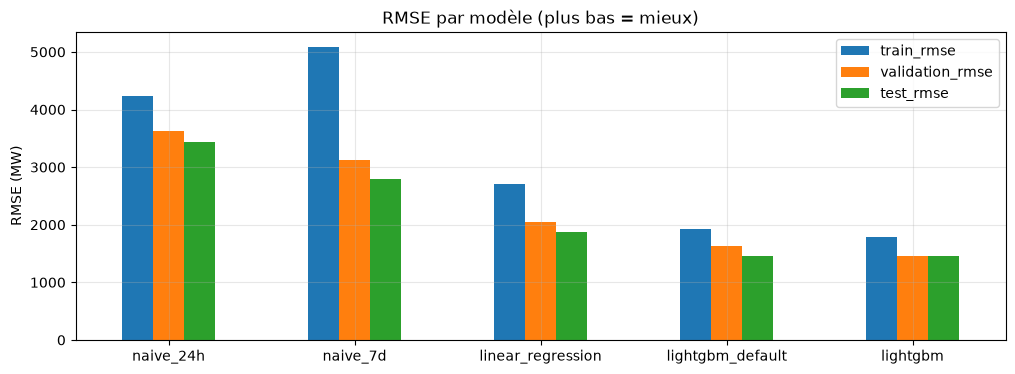

In [3]:
ax = table[["train_rmse", "validation_rmse", "test_rmse"]].plot.bar(rot=0, title="RMSE par modèle (plus bas = mieux)")
ax.set_ylabel("RMSE (MW)");

**Lecture :**

- les modèles naïfs donnent le niveau à battre ;
- la régression linéaire apporte déjà un gain net grâce au calendrier ;
- LightGBM divise encore l'erreur : il capte les interactions (ex. l'effet de l'heure dépend de la saison) ;
- **le choix se fait sur la validation**, le test ne sert qu'à confirmer. Choisir sur le test reviendrait à sur-apprendre le test.

## À quoi ressemblent les prévisions ?

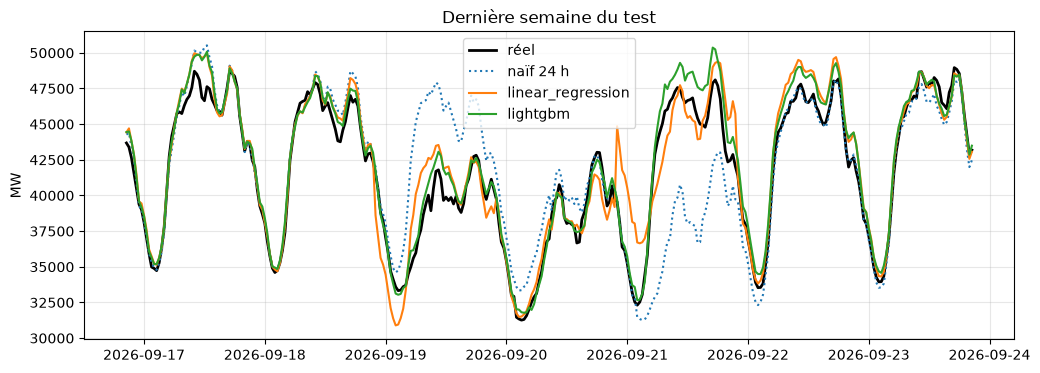

In [4]:
week = test[test["timestamp"] >= test["timestamp"].max() - pd.Timedelta(days=7)]
fig, ax = plt.subplots()
ax.plot(week["timestamp"], week[y], color="black", linewidth=2, label="réel")
ax.plot(week["timestamp"], week["lag_48"], linestyle=":", label="naïf 24 h")
for name in ["linear_regression", "lightgbm"]:
    ax.plot(week["timestamp"], models[name].predict(week[X]), label=name)
ax.set(title="Dernière semaine du test", ylabel="MW")
ax.legend();

La régression linéaire suit la forme générale mais rate l'amplitude des pics ; LightGBM colle beaucoup mieux au réel. **Le réglage des hyperparamètres de LightGBM et le contrôle du sur-apprentissage sont détaillés dans le notebook 04.**